# LAB 8

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

> Q1. Load the NORTHWIND dataset and explore all available tables. 

In [94]:
orders = pd.read_excel("Northwind.xlsx", sheet_name="Orders")
order_details = pd.read_excel("Northwind.xlsx", sheet_name="Order Details")
products = pd.read_excel("Northwind.xlsx", sheet_name="Products")
categories = pd.read_excel("Northwind.xlsx", sheet_name="Categories")
customers = pd.read_excel("Northwind.xlsx", sheet_name="Customers")
employees = pd.read_excel("Northwind.xlsx", sheet_name="Employees")

In [95]:
orders.head()

,OrderID,CustomerID,EmployeeID,OrderDate,RequiredDate,ShippedDate,ShipVia,Freight,ShipName,ShipAddress,ShipCity,ShipRegion,ShipPostalCode,ShipCountry
0,10248,VINET,5,1996-07-04,1996-08-01,1996-07-16,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,Reims,NaN,51100,France
1,10249,TOMSP,6,1996-07-05,1996-08-16,1996-07-10,1,11.61,Toms Spezialitäten,Luisenstr. 48,Münster,NaN,44087,Germany
2,10250,HANAR,4,1996-07-08,1996-08-05,1996-07-12,2,65.83,Hanari Carnes,"Rua do Paço, 67",Rio de Janeiro,RJ,05454-876,Brazil
3,10251,VICTE,3,1996-07-08,1996-08-05,1996-07-15,1,41.34,Victuailles en stock,"2, rue du Commerce",Lyon,NaN,69004,France
4,10252,SUPRD,4,1996-07-09,1996-08-06,1996-07-11,2,51.30,Suprêmes délices,"Boulevard Tirou, 255",Charleroi,NaN,B-6000,Belgium


In [96]:
order_details.head()

,OrderID,ProductID,UnitPrice,Quantity,Discount
0,10248,11,14.0,12,0.0
1,10248,42,9.8,10,0.0
2,10248,72,34.8,5,0.0
3,10249,14,18.6,9,0.0
4,10249,51,42.4,40,0.0


In [97]:
products.head()

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,False
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,False
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,False
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,False
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,True


In [98]:
categories.head()

,CategoryID,CategoryName,Description
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales"
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an..."
2,3,Confections,"Desserts, candies, and sweet breads"
3,4,Dairy Products,Cheeses
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal"


In [99]:
customers.head()

,CustomerID,CompanyName,ContactName,ContactTitle,Address,City,Region,PostalCode,Country,Phone,Fax
0,ALFKI,Alfred Futterkiste,Maria Anders,Sales Representative,Obere Str. 57,Berlin,NaN,12209,Germany,030-0074321,030-0076545
1,ANATR,Ana Trujillo Emparedados y helados,Ana Trujillo,Owner,Avda. de la Constitución 2222,México D.F.,NaN,05021,Mexico,(5) 555-4729,(5) 555-3745
2,ANTON,Antonio Moreno Taquería,Antonio Moreno,Owner,Mataderos 2312,México D.F.,NaN,05023,Mexico,(5) 555-3932,NaN
3,AROUT,Around the Horn,Thomas Hardy,Sales Representative,120 Hanover Sq.,London,NaN,WA1 1DP,UK,(171) 555-7788,(171) 555-6750
4,BERGS,Berglunds snabbköp,Christina Berglund,Order Administrator,Berguvsvägen 8,Luleå,NaN,S-958 22,Sweden,0921-12 34 65,0921-12 34 67


In [100]:
employees.head()

,EmployeeID,LastName,FirstName,Title,TitleOfCourtesy,BirthDate,HireDate,Address,City,Region,PostalCode,Country,HomePhone,Extension,ReportsTo
0,1,Davolio,Nancy,Sales Representative,Ms.,1948-12-08,1992-05-01,507 - 20th Ave. E._x000D_\nApt. 2A,Seattle,WA,98122,USA,(206) 555-9857,5467,2.0
1,2,Fuller,Andrew,"Vice President, Sales",Dr.,1952-02-19,1992-08-14,908 W. Capital Way,Tacoma,WA,98401,USA,(206) 555-9482,3457,NaN
2,3,Leverling,Janet,Sales Representative,Ms.,1963-08-30,1992-04-01,722 Moss Bay Blvd.,Kirkland,WA,98033,USA,(206) 555-3412,3355,2.0
3,4,Peacock,Margaret,Sales Representative,Mrs.,1937-09-19,1993-05-03,4110 Old Redmond Rd.,Redmond,WA,98052,USA,(206) 555-8122,5176,2.0
4,5,Buchanan,Steven,Sales Manager,Mr.,1955-03-04,1993-10-17,14 Garrett Hill,London,NaN,SW1 8JR,UK,(71) 555-4848,3453,2.0


---

> Q2. Calculate:  

In [101]:
order_details['Sales'] = order_details['Quantity'] * order_details['UnitPrice']

            a) Total sales per product  

In [102]:
df = order_details.merge(products, on="ProductID") \
                   .merge(categories, on="CategoryID") \
                   .merge(orders, on="OrderID") \
                   .merge(customers, on="CustomerID") \
                   .merge(employees, on="EmployeeID")

df.groupby("ProductName")["Sales"].sum().sort_values(ascending=False)

ProductName
Côte de Blaye                149984.20
Thüringer Rostbratwurst       87736.40
Raclette Courdavault          76296.00
Camembert Pierrot             50286.00
Tarte au sucre                49827.90
                               ...    
Longlife Tofu                  2566.00
Laughing Lumberjack Lager      2562.00
Genen Shouyu                   1813.50
Geitost                        1713.50
Chocolade                      1542.75
Name: Sales, Length: 77, dtype: float64

            b) Total sales per category 

In [103]:
df.groupby("CategoryName")["Sales"].sum().sort_values(ascending=False)

CategoryName
Beverages         286526.95
Dairy Products    251330.50
Meat/Poultry      178188.80
Confections       177099.10
Seafood           141623.09
Condiments        113694.75
Produce           105268.60
Grains/Cereals    100726.80
Name: Sales, dtype: float64

> Q3. Identify the top 5 customers by revenue.  

In [104]:
df.groupby('CustomerID')['OrderID'].value_counts().head(5)

CustomerID  OrderID
ALFKI       10643      3
            10702      2
            10835      2
            10952      2
            11011      2
Name: OrderID, dtype: int64

> Q4. Group data by country and compute total orders.  

In [107]:
df.groupby("ShipCountry")["OrderID"].count().sort_values(ascending=False)

ShipCountry
USA            352
Germany        328
Brazil         203
France         184
UK             135
Austria        125
Venezuela      118
Sweden          97
Canada          75
Mexico          72
Belgium         56
Ireland         55
Spain           54
Finland         54
Italy           53
Switzerland     52
Denmark         46
Argentina       34
Portugal        30
Poland          16
Norway          16
Name: OrderID, dtype: int64

> Q5. Find the monthly sales trend using aggregation.

In [108]:
orders["OrderDate"] = pd.to_datetime(orders["OrderDate"])
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

In [109]:
df.groupby(df["OrderDate"].dt.to_period("M"))["Sales"].sum()

OrderDate
1996-07     30192.10
1996-08     26609.40
1996-09     27636.00
1996-10     41203.60
1996-11     49704.00
1996-12     50953.40
1997-01     66692.80
1997-02     41207.20
1997-03     39979.90
1997-04     55699.39
1997-05     56823.70
1997-06     39088.00
1997-07     55464.93
1997-08     49981.69
1997-09     59733.02
1997-10     70328.50
1997-11     45913.36
1997-12     77476.26
1998-01    100854.72
1998-02    104561.95
1998-03    109825.45
1998-04    134630.56
1998-05     19898.66
Freq: M, Name: Sales, dtype: float64

> Q6. Perform a groupby operation to calculate average order value per employee. 

In [110]:
df.groupby("LastName")["Sales"].mean().sort_values(ascending=False)

LastName
King         802.818125
Dodsworth    775.364486
Fuller       737.548797
Leverling    663.711215
Buchanan     645.878205
Peacock      595.684405
Davolio      585.923797
Callahan     512.696269
Suyama       465.464881
Name: Sales, dtype: float64

> Q7. Create a bar chart showing category-wise sales. 

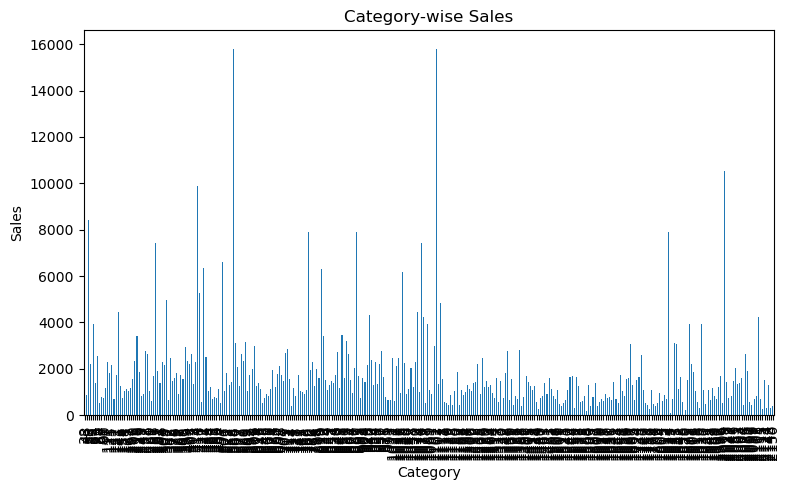

In [111]:
plt.figure(figsize=(8,5))
df.groupby("CategoryName")["Sales"].plot(kind="bar")
plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

> Q8. Visualize country-wise revenue contribution.  

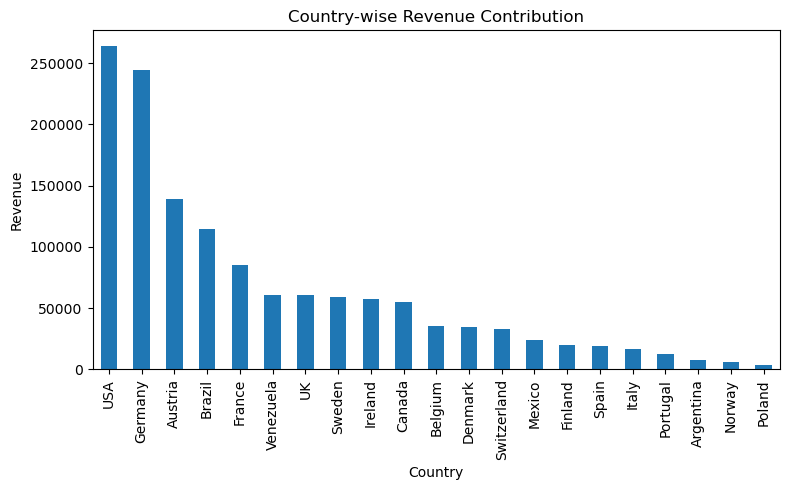

In [113]:
plt.figure(figsize=(8,5))
country_revenue = df.groupby("ShipCountry")["Sales"].sum().sort_values(ascending=False)
country_revenue.plot(kind="bar")
plt.title("Country-wise Revenue Contribution")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

> Q9. Interpret results and write 2 business insights based on aggregation. 

Interpretation:
The sales analysis shows that some products and categories contribute more revenue than others. Beverages and Dairy Products have the highest sales, and countries like USA and Germany have the most orders. Monthly sales also show an overall increasing trend over time.

Business Insights:

The company should focus more on high-selling categories like Beverages and Dairy Products to increase profit.
Since USA and Germany are major markets, the company can improve business by targeting these countries with better sales and marketing strategies.